# Visualisation de la durée de séjour aux urgences avec PROC BOX


## Résumé

Une analyse des opérations hospitalières qui utilise PROC BOXPLOT (avec l'alias PROC BOX) pour comparer la durée de séjour aux urgences entre trois services cliniques. Des boîtes à moustaches schématiques côte à côte montrent d'un coup d'œil la médiane, les quartiles, la moyenne et les valeurs aberrantes de séjour prolongé de chaque service.

Sur 100 passages simulés, la durée de séjour médiane augmente régulièrement, de **40,0 heures en Médecine** à **50,4 heures en Chirurgie** puis à **60,5 heures en Traumatologie**, et les moyennes suivent le même ordre (41,6, 54,6, 62,8 heures). La Chirurgie présente trois valeurs aberrantes élevées au-dessus de sa moustache supérieure (jusqu'à 84,3 heures) — les cas d'attente qui consomment le plus d'heures-lit. Le notebook trace la comparaison de trois façons : un graphique schématique, une superposition de la tendance des moyennes et une disposition horizontale.

## Sources de données

Toutes les données sont générées en ligne par le premier DATA step (`call streaminit(20260531)`) ; aucune entrée externe ou réseau n'est utilisée.

**`ed_los`** — une ligne par passage aux urgences (100 lignes)

| Variable | Type | Description |
|----------|------|-------------|
| `PatientID` | Num | Identifiant séquentiel du passage (1-100) |
| `Department` | Char(12) | Service d'admission : Medicine, Surgery, Trauma |
| `Severity` | Char(8) | Gravité au triage : Routine (~55 %), Urgent (~30 %), Critical (~15 %) |
| `LOS_Hours` | Num | Durée de séjour en heures ; une moyenne pilotée par le service et la gravité plus un bruit normal, avec un choc occasionnel de séjour prolongé (libellée « Length of Stay (hours) ») |

Le mélange obtenu est de 34 passages en Médecine / 36 en Chirurgie / 30 en Traumatologie, et de 51 Routine / 35 Urgent / 14 Critical par gravité de triage.

# Visualisation de la durée de séjour aux urgences avec PROC BOX

La durée de séjour (LOS) est l'une des métriques opérationnelles les plus surveillées dans un service d'urgences hospitalier : elle détermine la disponibilité des lits, l'affectation du personnel, le débit des patients et les indicateurs de qualité. Les moyennes seules masquent l'histoire — ce qui importe à une équipe des opérations, c'est la *dispersion* des séjours, les *valeurs aberrantes* qui immobilisent les ressources, et la façon dont les distributions diffèrent entre services cliniques.

PROC BOX (un alias de PROC BOXPLOT) est conçu précisément pour cette comparaison. Il trace des boîtes à moustaches côte à côte, marquant la médiane, les quartiles, la moyenne et les observations extrêmes de chaque groupe, de sorte qu'un analyste peut lire d'un coup d'œil la forme de la distribution de la LOS de chaque service.

Dans ce notebook, nous :

1. Générons un jeu de données synthétique de passages aux urgences adapté à l'environnement à 100 observations.
2. Produisons une boîte à moustaches schématique de la LOS par service, avec le tableau statistique correspondant.
3. Superposons une ligne de tendance des moyennes avec `BOXCONNECT=MEAN` pour rendre explicite le gradient entre services.
4. Retraçons la même comparaison horizontalement avec `HORIZONTAL`.

## Étape 1 — Générer des données synthétiques de passages aux urgences

Nous simulons 100 passages aux urgences. Chaque patient est affecté à l'un des trois services cliniques (Medicine, Surgery, Trauma) et à une gravité de triage (Routine, Urgent, Critical). La durée de séjour est construite à partir d'une base spécifique au service, décalée vers le haut pour les patients de gravité plus élevée, avec un bruit distribué normalement. Une petite fraction des passages reçoit un choc supplémentaire de séjour prolongé pour imiter la lourde queue à droite que présentent toujours les vraies données d'urgences (attente, admissions en attente d'un lit d'hospitalisation). La graine fixe dans `call streaminit` rend le jeu de données entièrement reproductible.

In [1]:
options linesize=96;

DONNÉES ed_los;
   APPELER streaminit(20260531);
   LONGUEUR Department $ 14 Severity $ 10;
   FAIRE PatientID = 1 JUSQU_À 100;
      d = rand('integer', 1, 3);
      SI d = 1 ALORS Department = 'Médecine';
      SINON SI d = 2 ALORS Department = 'Chirurgie';
      SINON Department = 'Traumatologie';

      u = rand('uniform');
      SI u < 0.55 ALORS s = 1;
      SINON SI u < 0.85 ALORS s = 2;
      SINON s = 3;
      SI s = 1 ALORS Severity = 'Courant';
      SINON SI s = 2 ALORS Severity = 'Urgent';
      SINON Severity = 'Critique';

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      SI rand('uniform') < 0.06 ALORS
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      SI LOS_Hours < 2 ALORS LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      SORTIE;
   FIN;
   SUPPRIMER d u s BASE;
   ÉTIQUETTE LOS_Hours = "Durée de séjour (heures)"
         Department = "Service"
         Severity   = "Gravité";
EXÉCUTER;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Étape 2 — Trier par la variable de groupe

PROC BOX attend que la variable de groupe (axe horizontal) soit triée afin que les observations de chaque groupe soient contiguës. Nous trions par `Department` avant de tracer.

In [2]:
PROCÉDURE TRIER DONNÉES=ed_los;
   PAR Department;
EXÉCUTER;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Étape 3 — Boîte à moustaches schématique

L'analyse centrale. La syntaxe `PLOT analysis-var * group-var` demande une boîte par service. `BOXSTYLE=SCHEMATIC` produit un graphique schématique de Tukey classique : les moustaches s'étendent jusqu'aux observations les plus extrêmes situées dans 1,5 fois l'écart interquartile, et tout point au-delà est dessiné individuellement comme valeur aberrante — idéal pour repérer les cas de séjour prolongé qui pèsent sur la capacité.

`NOHLABEL` supprime le libellé redondant de l'axe horizontal puisque les noms des services parlent d'eux-mêmes. À côté du graphique, PROC BOXPLOT imprime un tableau statistique donnant, pour chaque service, N, le minimum, les quartiles, la médiane, le maximum, la moyenne et l'écart-type.

                            Durée de séjour aux urgences par service                            

                           Durée de séjour aux urgences par service

                                     The BOXPLOT Procedure

Schematic Plots for Durée de séjour (heures)

Service               N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Médecine             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traumatologie        30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Durée de séjour aux urgences par service.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


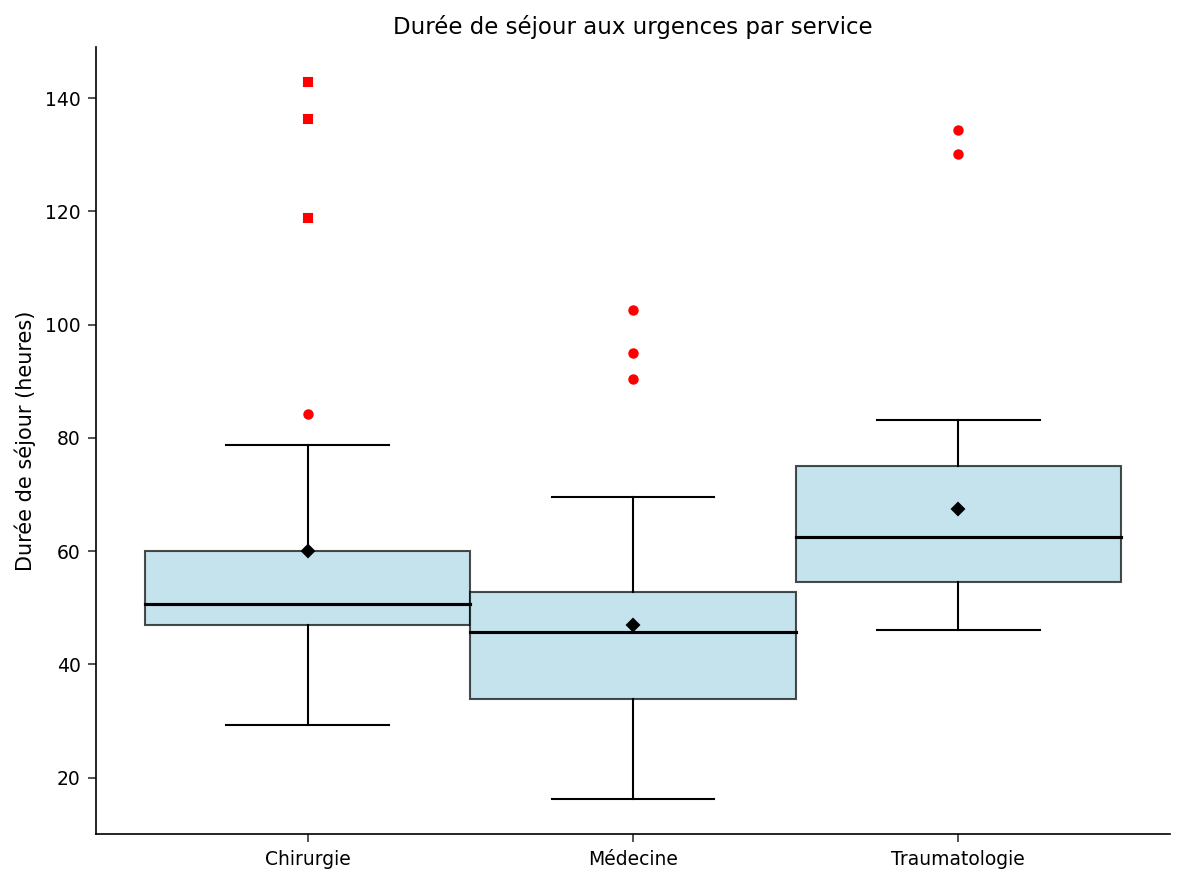

In [3]:
TITRE "Durée de séjour aux urgences par service";
PROCÉDURE boxplot DONNÉES=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
EXÉCUTER;

## Étape 4 — Superposer une ligne de tendance des moyennes

Pour rendre explicite le gradient d'un service à l'autre, nous ajoutons `BOXCONNECT=MEAN`. PROC BOXPLOT trace alors une ligne reliant la moyenne de chaque boîte (les marqueurs en losange), transformant les trois distributions séparées en une seule tendance lisible. Comme les services sont ordonnés Medicine → Surgery → Trauma, la ligne de liaison ascendante résume en un seul trait l'escalade de la durée de séjour moyenne — un repère utile pour un tableau de bord des opérations.

                  Durée de séjour aux urgences par service - tendance moyenne                   

                 Durée de séjour aux urgences par service - tendance moyenne

                                     The BOXPLOT Procedure

Schematic Plots for Durée de séjour (heures)

Service               N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Médecine             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traumatologie        30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Durée de séjour aux urgences par service - tendance moyenne.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


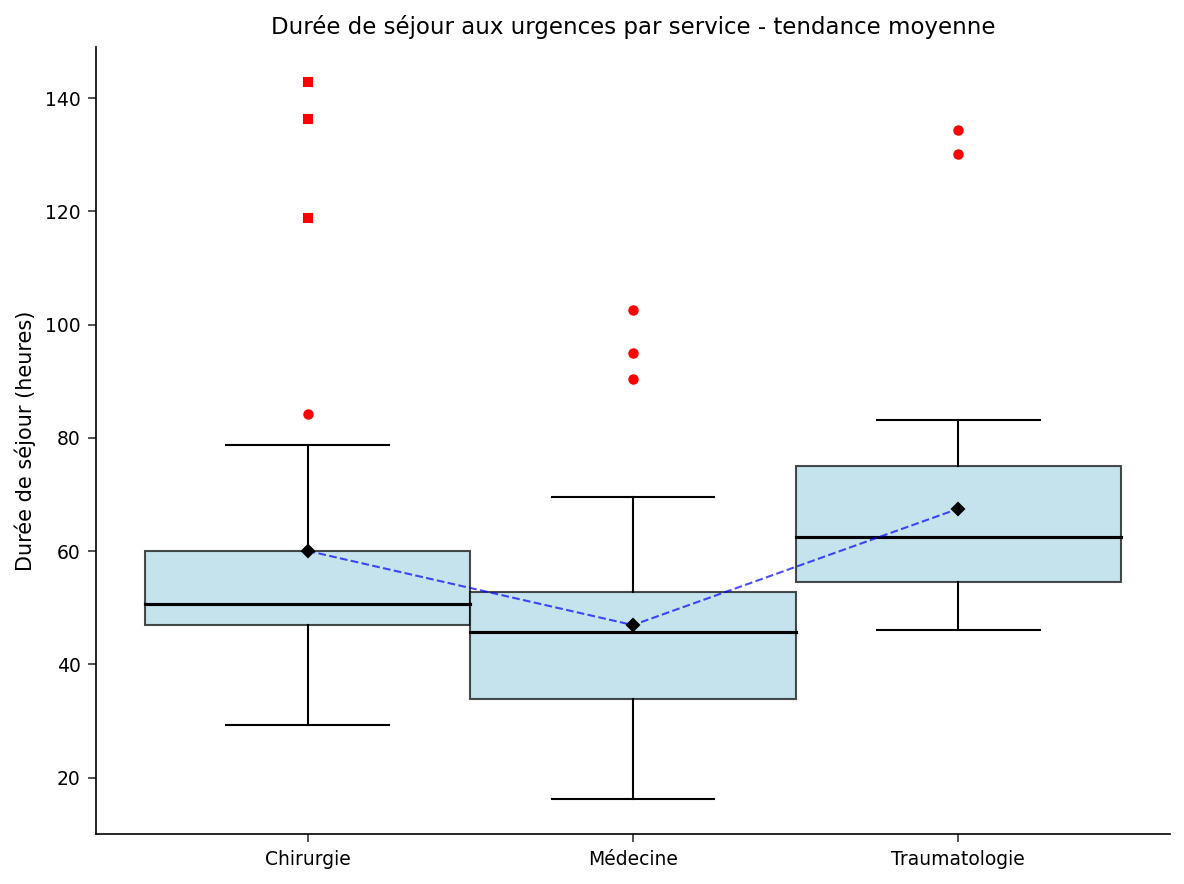

In [4]:
TITRE "Durée de séjour aux urgences par service - tendance moyenne";
PROCÉDURE boxplot DONNÉES=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
EXÉCUTER;

## Étape 5 — Disposition horizontale

La même comparaison se lit naturellement sur le côté. L'ajout de `HORIZONTAL` échange les axes de sorte que les boîtes s'étendent de gauche à droite avec la réponse sur l'axe des x — une disposition qui s'adapte mieux quand les noms de services sont longs ou nombreux, et que de nombreux tableaux de bord des opérations préfèrent. Les statistiques sont identiques à la vue verticale ; seule l'orientation change.

                     Durée de séjour aux urgences par service - horizontal                      

                    Durée de séjour aux urgences par service - horizontal

                                     The BOXPLOT Procedure

Schematic Plots for Durée de séjour (heures)

Service               N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Médecine             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traumatologie        30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Durée de séjour aux urgences par service - horizontal.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


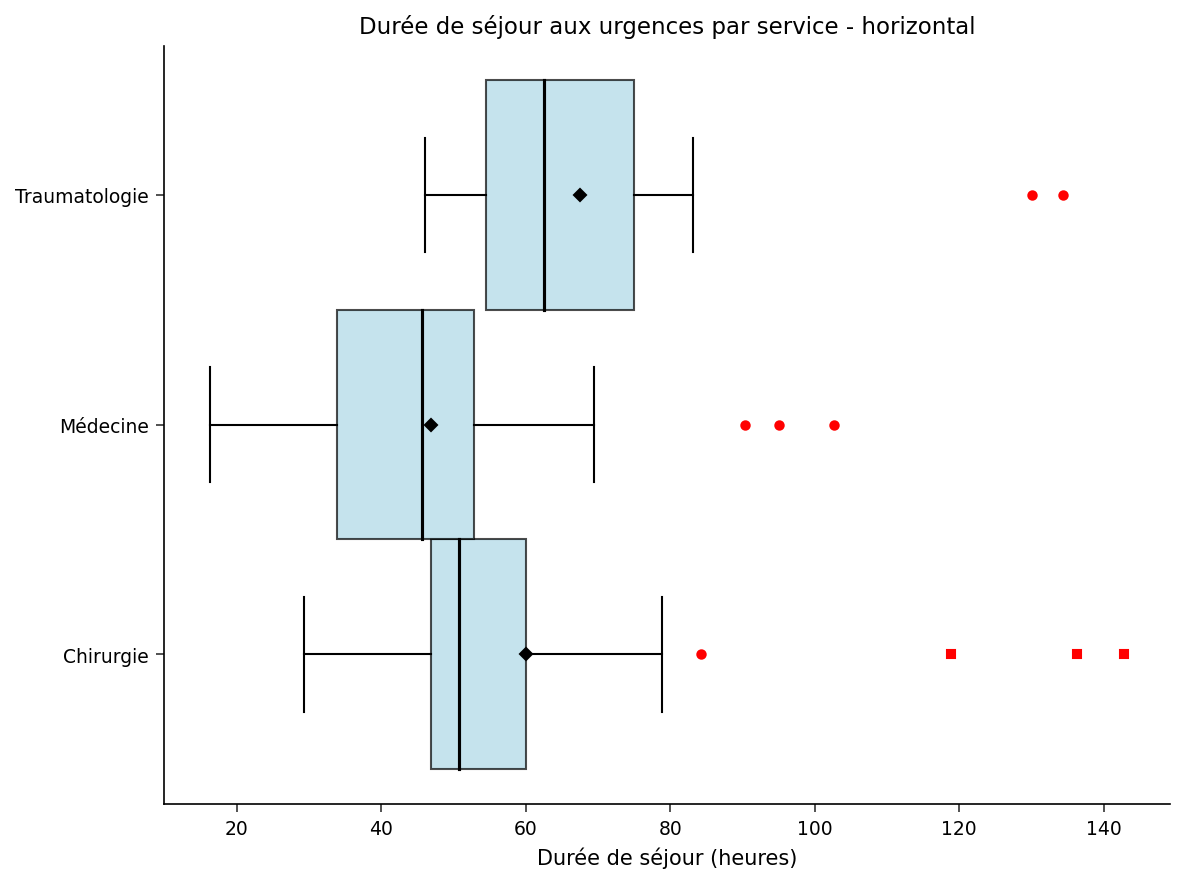

In [5]:
TITRE "Durée de séjour aux urgences par service - horizontal";
PROCÉDURE boxplot DONNÉES=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
EXÉCUTER;

## Interpréter les résultats

Les boîtes à moustaches et le tableau statistique correspondant traduisent les données brutes de LOS en une image opérationnellement exploitable :

- **Un gradient de service clair.** La durée de séjour médiane augmente de façon monotone entre les trois services : **Medicine 40,0 h → Surgery 50,4 h → Trauma 60,5 h**. Les moyennes racontent la même histoire (41,6, 54,6, 62,8 h), et la ligne `BOXCONNECT=MEAN` de l'Étape 4 dessine cette escalade comme une seule tendance ascendante. Les patients de Traumatologie restent en moyenne environ 50 % plus longtemps que les patients de Médecine.

- **La variabilité compte autant que la médiane.** L'écart interquartile (la hauteur de la boîte) est le plus large pour la Médecine (Q1 32,8 h à Q3 51,2 h, une dispersion de 18,3 heures) et le plus étroit pour la Traumatologie (Q1 54,5 h à Q3 68,5 h, une dispersion de 14,0 heures). La Médecine n'est donc pas seulement le service le plus court, mais aussi le moins prévisible — la propriété qui complique les prévisions de gestion des lits.

- **Les valeurs aberrantes signalent les cas d'attente.** Les moustaches schématiques s'arrêtent à 1,5 × IQR, de sorte que les trois points rouges au-dessus de la moustache supérieure de la Chirurgie (culminant à 84,3 h) ressortent comme de véritables passages de séjour prolongé — exactement les cas d'attente qui consomment une part disproportionnée d'heures-lit. La Médecine et la Traumatologie ne présentent aucun point au-delà de leurs moustaches dans cet échantillon.

- **L'étendue raconte l'histoire de la planification de capacité.** Les séjours observés s'étendent de 16,3 à 69,5 h en Médecine, de 29,3 à 84,3 h en Chirurgie, et de 46,1 à 83,2 h en Traumatologie. La Traumatologie ne produit jamais de séjour court (son minimum, 46,1 h, dépasse la médiane de la Médecine), ce à quoi une équipe des opérations s'attendrait du service le plus gourmand en ressources.

Ensemble, ces vues offrent à une équipe de direction des urgences une base défendable, tenant compte de la distribution, pour l'affectation du personnel et la planification de capacité — bien plus instructive que la simple comparaison de la LOS moyenne par service.